In [1]:
import pandas as pd

from pathlib import Path

In [5]:
# Directory containing this Python file
BASE_DIR = Path.cwd()

# Data file relative to this script
DATA_DIR = BASE_DIR / "recipe_matching_llm_100"

In [10]:
df = pd.read_csv(DATA_DIR / "ingredient_matches_llm.csv")
print(df.index.size)
df.head()

200


,run_id,run_name,model,recipe_id,ingredient_idx,ingredient,name,preparation,dequantified,unit,...,relevant_steps,prompt_tokens,completion_tokens,total_tokens,price_estimate_usd,ts,ts_year,ts_month,ts_date,ts_time
0,85ae932c534c4560a7b2268ea43ce524,match_experiments_0__gpt-4o-mini__seed42__2026...,gpt-4o-mini,27257,3,2 Tbsp. olive oil,olive oil,NaN,Tbsp. olive oil,Tbsps,...,NaN,571,28,599,0.000102,2026-06-07 00:38:10.127151+00:00,2026,6,7,00:38:10
1,85ae932c534c4560a7b2268ea43ce524,match_experiments_0__gpt-4o-mini__seed42__2026...,gpt-4o-mini,104902,0,8 ears fresh corn (or frozen),fresh corn,NaN,ears fresh corn (or frozen),ears,...,Cook corn in water to cover 5 to 7 minutes or ...,641,28,669,0.000113,2026-06-07 00:38:10.129428+00:00,2026,6,7,00:38:10
2,85ae932c534c4560a7b2268ea43ce524,match_experiments_0__gpt-4o-mini__seed42__2026...,gpt-4o-mini,27257,5,1/2 c. dry white wine,dry white wine,NaN,c. dry white wine,c,...,NaN,615,28,643,0.000109,2026-06-07 00:38:10.130994+00:00,2026,6,7,00:38:10
3,85ae932c534c4560a7b2268ea43ce524,match_experiments_0__gpt-4o-mini__seed42__2026...,gpt-4o-mini,27257,1,1/2 tsp. dried thyme,dried thyme,NaN,tsp. dried thyme,tsps,...,NaN,602,30,632,0.000108,2026-06-07 00:38:10.151571+00:00,2026,6,7,00:38:10
4,85ae932c534c4560a7b2268ea43ce524,match_experiments_0__gpt-4o-mini__seed42__2026...,gpt-4o-mini,27257,2,2 cloves thinly sliced garlic,garlic,thinly sliced,cloves thinly sliced garlic,cloves,...,NaN,556,27,583,0.000100,2026-06-07 00:38:10.180748+00:00,2026,6,7,00:38:10


In [13]:
pd.set_option('display.max_rows', 500)

<Axes: >

,ingredient,name,preparation,dequantified,llm_description,llm_certainty,llm_rationale
110,1/4 c. water,water,NaN,c. water,NaN,0.00,Water is not represented in the candidates.
23,1 large Bermuda onion,Bermuda onion,NaN,large Bermuda onion,NaN,0.00,No raw Bermuda onion entry available; closest ...
94,6 c. sugar,sugar,NaN,c. sugar,NaN,0.00,No suitable raw sugar entry found among candid...
177,few drops yellow food coloring,yellow food coloring,NaN,few drops yellow food coloring,NaN,0.00,"No suitable raw, unbranded entry for food colo..."
175,4 Tbsp. Crisco,Crisco,NaN,Tbsp. Crisco,NaN,0.00,"No suitable match for Crisco, which is a short..."
173,2 c. sugar,sugar,NaN,c. sugar,NaN,0.00,No suitable raw sugar entry found among candid...
172,1 (6 oz.) graham cracker crust,graham cracker crust,NaN,(6 oz.) graham cracker crust,NaN,0.00,"No raw, generic graham cracker crust entry ava..."
143,3 c. sugar,sugar,NaN,c. sugar,NaN,0.00,No suitable raw sugar entry found among candid...
34,1 large onion,onion,NaN,large onion,NaN,0.00,"No raw, unbranded onion entry available."
95,4 pkg. lemon jello,"pkg., lemon jello",NaN,pkg. lemon jello,NaN,0.00,No suitable raw or generic entry for lemon jello.


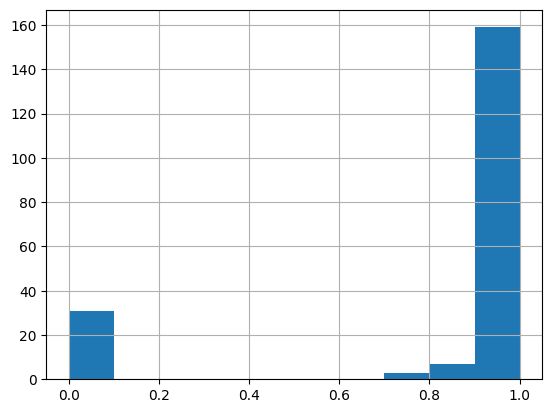

In [19]:
short_cols = ['ingredient', 'name', 'preparation', 'dequantified', 'llm_description','llm_certainty', 'llm_rationale']

display(df['llm_certainty'].hist())
display(df[short_cols].sort_values(by='llm_certainty', ascending=True))

In [29]:
pd.set_option('display.max_colwidth', 100)

In [33]:
df_cand = pd.read_csv(DATA_DIR / "ingredient_candidates_top10.csv")

CERTAINTY_THRESHOLD = 0.5
KEY = ['recipe_id', 'ingredient_idx']  # an ingredient is unique only on this pair

# Ingredient-side context for the low-confidence picks
context_cols = ['ingredient', 'name', 'llm_description', 'llm_certainty', 'llm_rationale']
low_certainty = df.loc[df['llm_certainty'] < CERTAINTY_THRESHOLD, KEY + context_cols]

# Candidate rows for those ingredients, with the ingredient context attached
problem_candidates = (
    low_certainty.merge(df_cand, on=KEY, how='inner')
                 .sort_values(KEY + ['rank'])
                 .reset_index(drop=True)
)

# Drop id/filler columns that don't describe the comparison, metrics, or rationale
filler = ['run_id', 'recipe_id', 'ingredient_idx', 'fdc_id', 'data_type', 'ts']
problem_candidates = problem_candidates.drop(columns=filler, errors='ignore')

print(f"{len(low_certainty)} low-certainty ingredients -> {len(problem_candidates)} candidate rows")
problem_candidates






31 low-certainty ingredients -> 310 candidate rows


,run_id,recipe_id,ingredient_idx,rank,fdc_id,data_type,description,lexical_dequant,dequant_sem,retrieval_score,staged_final_score,staged_base_score,staged_prep_score,in_llm_prompt,is_staged_top1,is_llm_pick,ts,llm_certainty
0,85ae932c534c4560a7b2268ea43ce524,111299,0,1,393409,branded_food,"HOGWASH, CONDIMENT",0.0150,0.5062,0.5062,0.2654,0.1020,0.4362,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
1,85ae932c534c4560a7b2268ea43ce524,111299,0,2,367492,branded_food,"4C, BREAD CRUMBS, SEASONED, SALT FREE",0.0203,0.4768,0.4768,0.0000,0.0815,0.3662,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
2,85ae932c534c4560a7b2268ea43ce524,111299,0,3,413399,branded_food,VINEGAR,0.0000,0.4715,0.4715,0.2620,0.0969,0.4362,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
3,85ae932c534c4560a7b2268ea43ce524,111299,0,4,172237,sr_legacy_food,"Vinegar, distilled",0.1050,0.4707,0.4707,0.2992,0.1561,0.4309,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
4,85ae932c534c4560a7b2268ea43ce524,111299,0,5,367498,branded_food,"4C, BREAD CRUMBS, SEASONED",0.0250,0.4534,0.4534,0.0000,0.0729,0.3662,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
5,85ae932c534c4560a7b2268ea43ce524,111299,0,6,172241,sr_legacy_food,"Vinegar, balsamic",0.0769,0.4436,0.4436,0.2880,0.1368,0.4362,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
6,85ae932c534c4560a7b2268ea43ce524,111299,0,7,1119086,branded_food,RICE VINEGAR,0.0176,0.4403,0.4403,0.2586,0.0917,0.4362,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
7,85ae932c534c4560a7b2268ea43ce524,111299,0,8,1115533,branded_food,"VINEGAR, APPLE CIDER",0.0286,0.4403,0.4403,0.2575,0.0899,0.4362,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
8,85ae932c534c4560a7b2268ea43ce524,111299,0,9,386322,branded_food,"DELALLO, CAPERS IN VINEGAR",0.0250,0.4398,0.4398,0.2548,0.0858,0.4362,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
9,85ae932c534c4560a7b2268ea43ce524,111299,0,10,168415,sr_legacy_food,"Gourd, dishcloth (towelgourd), cooked, boiled, drained, without salt",0.0800,0.4361,0.4361,0.1912,0.1276,0.3530,True,False,False,2026-06-07 00:38:11.605325+00:00,0.0
